In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

print(os.getcwd())

C:\Users\admin\Desktop\MedAssist AI\notebooks


In [3]:
dataset2 = pd.read_csv("../cleaned_datasets/dataset2_clean.csv")

In [4]:
dataset2.head()

,Disease,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,Panic Disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,Panic Disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Panic Disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Panic Disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,Panic Disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print("Shape:", dataset2.shape)
print("\nColumns:", len(dataset2.columns))
print("\nData Types:")
print(dataset2.dtypes)

Shape: (189647, 378)

Columns: 378

Data Types:
Disease                             object
anxiety and nervousness              int64
depression                           int64
shortness of breath                  int64
depressive or psychotic symptoms     int64
                                     ...  
hip weakness                         int64
back swelling                        int64
ankle stiffness or tightness         int64
ankle weakness                       int64
neck weakness                        int64
Length: 378, dtype: object


In [6]:
dataset2.describe()

,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
count,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,...,189647.0,189647.0,189647.0,189647.0,189647.000000,189647.0,189647.0,189647.0,189647.000000,189647.0
mean,0.037607,0.041398,0.085923,0.058672,0.096780,0.066945,0.038714,0.038883,0.038319,0.024219,...,0.0,0.0,0.0,0.0,0.001334,0.0,0.0,0.0,0.000095,0.0
std,0.190244,0.199209,0.280251,0.235011,0.295658,0.249928,0.192913,0.193316,0.191965,0.153728,...,0.0,0.0,0.0,0.0,0.036500,0.0,0.0,0.0,0.009742,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,1.000000,0.0


In [7]:
print("Total Missing Values:", dataset2.isnull().sum().sum())

Total Missing Values: 0


In [ ]:
## Disease Distribution

In this section, we analyze the number of unique diseases and the distribution of records across different disease classes.
This helps identify whether the dataset is balanced before model training.

In [9]:
print("Number of Unique Diseases:", dataset2["Disease"].nunique())

Number of Unique Diseases: 773


In [ ]:
##The dataset contains 773 unique disease classes, making it a multi-class classification problem.
##The machine learning model will learn symptom patterns corresponding to each disease and predict the most probable
##disease based on user-selected symptoms.

In [10]:
disease_counts = dataset2["Disease"].value_counts()

print(disease_counts.head(10))

Disease
Cystitis                          1219
Nose Disorder                     1218
Vulvodynia                        1218
Complex Regional Pain Syndrome    1217
Spondylosis                       1216
Vaginal Cyst                      1215
Hypoglycemia                      1215
Conjunctivitis Due To Allergy     1215
Esophagitis                       1215
Peripheral Nerve Disorder         1215
Name: count, dtype: int64


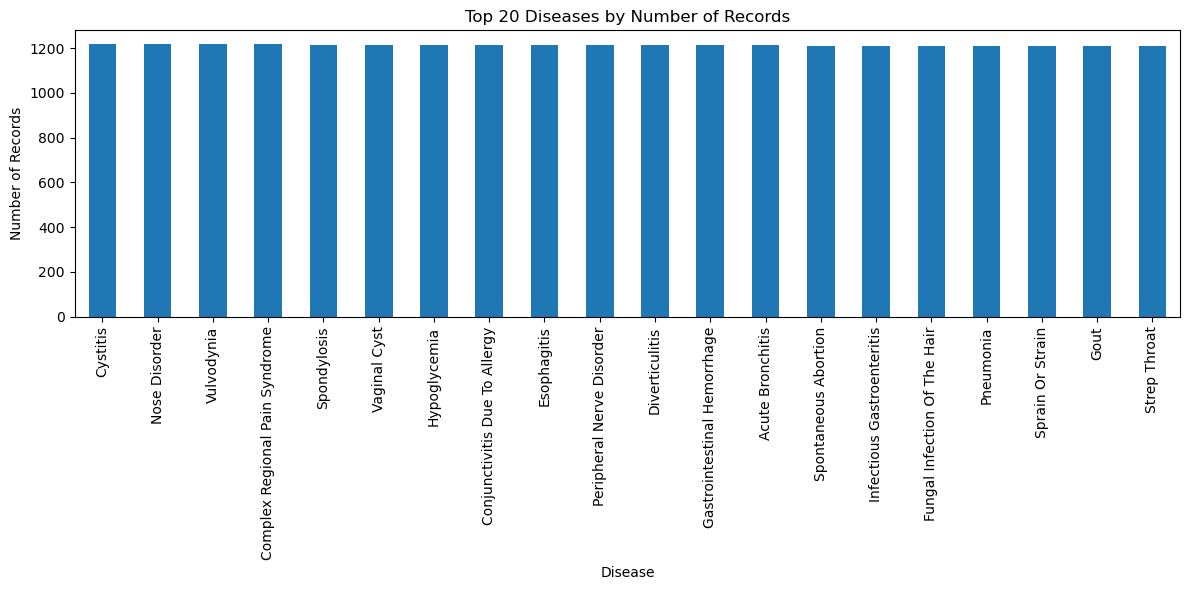

In [13]:
plt.figure(figsize=(12,6))

disease_counts.head(20).plot(kind="bar")

plt.title("Top 20 Diseases by Number of Records")
plt.xlabel("Disease")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [14]:
print(disease_counts.describe())

count     773.000000
mean      245.338939
std       333.650389
min         1.000000
25%        10.000000
50%        77.000000
75%       315.000000
max      1219.000000
Name: count, dtype: float64


In [ ]:
### Observation

- The dataset contains multiple disease classes.
- Some diseases have more training records than others.
- Understanding the class distribution is important before training the machine learning model.

In [15]:
symptom_counts = dataset2.drop(columns=["Disease"]).sum().sort_values(ascending=False)

print(symptom_counts.head(20))

sharp abdominal pain                25152
vomiting                            22018
cough                               18899
headache                            18775
nausea                              18729
back pain                           18578
sharp chest pain                    18354
fever                               16709
shortness of breath                 16295
nasal congestion                    13125
leg pain                            13105
dizziness                           12696
abnormal appearing skin             12138
lower abdominal pain                12115
skin swelling                       11384
depressive or psychotic symptoms    11127
burning abdominal pain              11068
sore throat                         11061
arm pain                             9893
skin rash                            9713
dtype: int64


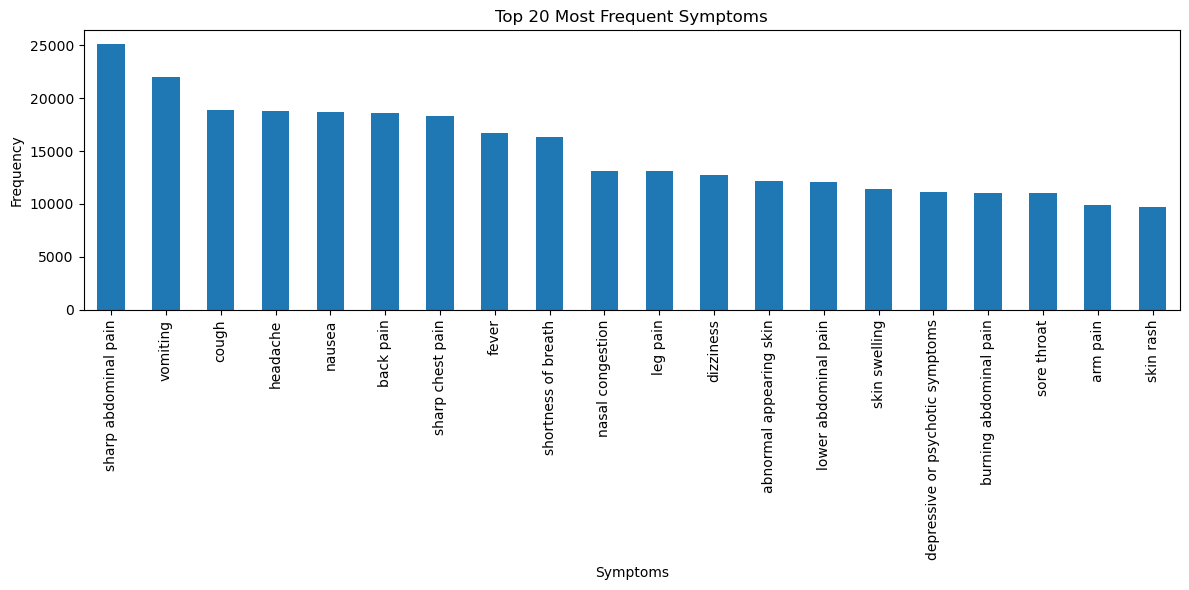

In [16]:
plt.figure(figsize=(12,6))

symptom_counts.head(20).plot(kind="bar")

plt.title("Top 20 Most Frequent Symptoms")
plt.xlabel("Symptoms")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [ ]:
### Observation

- Some symptoms occur much more frequently than others.
- Highly frequent symptoms may be useful predictive features.
- Rare symptoms may still be important for distinguishing specific diseases.
- The symptom frequency analysis shows that symptoms such as pain, fever, cough, fatigue, and headache occur frequently across many diseases.
- These represent common clinical manifestations.
- Less frequent symptoms may provide stronger discriminatory power for distinguishing between diseases.

In [17]:
# Count number of symptoms present in each record

symptom_per_patient = dataset2.drop(columns=["Disease"]).sum(axis=1)

print(symptom_per_patient.head())

0    7
1    5
2    9
3    6
4    5
dtype: int64


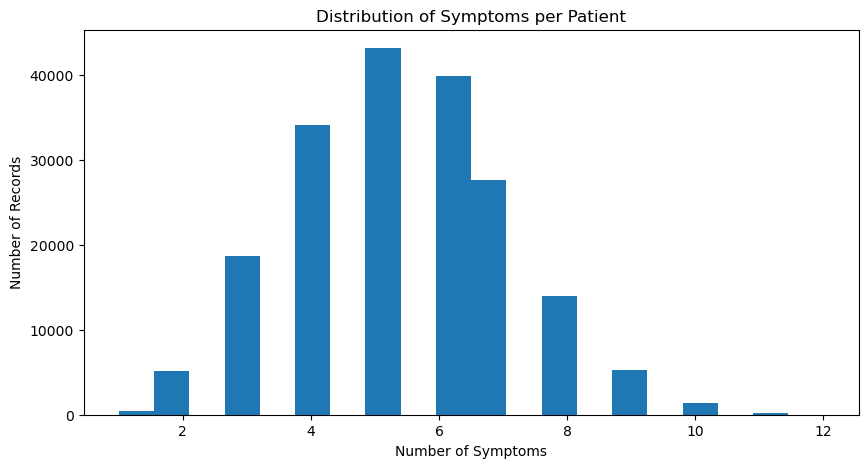

In [18]:
plt.figure(figsize=(10,5))

plt.hist(symptom_per_patient, bins=20)

plt.title("Distribution of Symptoms per Patient")
plt.xlabel("Number of Symptoms")
plt.ylabel("Number of Records")

plt.show()

In [ ]:
### Observation

Most records contain a moderate number of symptoms. Very few records contain either very few or a very large number of symptoms.

In [19]:
top20 = symptom_counts.head(20).index

corr = dataset2[top20].corr()

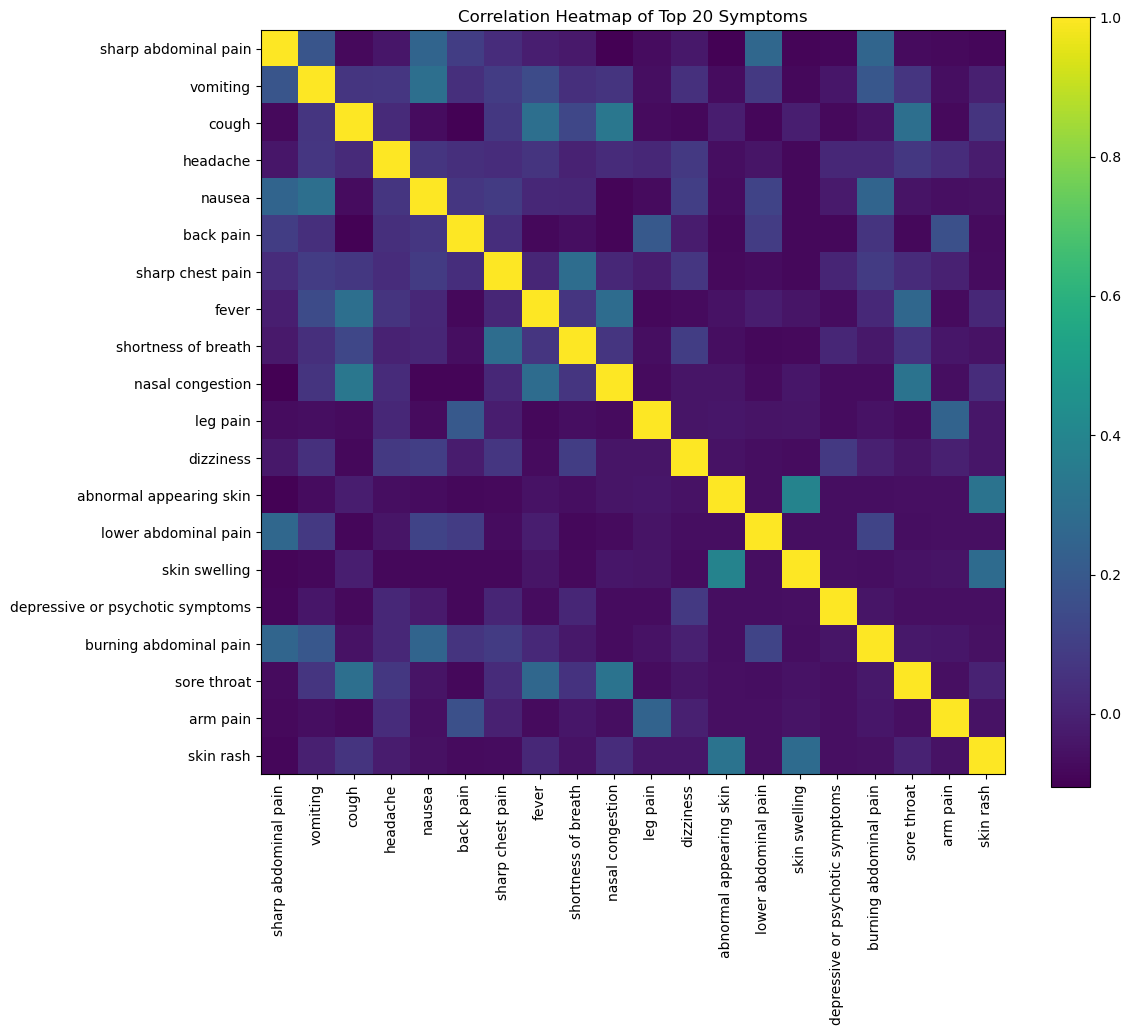

In [20]:
plt.figure(figsize=(12,10))

plt.imshow(corr)

plt.xticks(range(len(top20)), top20, rotation=90)
plt.yticks(range(len(top20)), top20)

plt.title("Correlation Heatmap of Top 20 Symptoms")

plt.colorbar()

plt.show()

In [ ]:
### Observation

The heatmap shows the correlation between the most common symptoms. Some symptoms frequently occur together, while others show little or no relationship.